In [2]:
import torch
import hdf5plugin
import h5py
from omegaconf import OmegaConf

from transformers import AutoImageProcessor, AutoModel

from transpressor.module import JEPA, ARPredictor, Transpressor

from tqdm import tqdm

from matplotlib import pyplot as plt

In [3]:
def build_jepa(config, checkpoint, device):
    pixel_encoder = AutoModel.from_pretrained(config.pixel_encoder.model_name)

    action_encoder = Transpressor(
        input_dim=config.transpressor.input_dim,
        hidden_dim=config.transpressor.hidden_dim,
        condition_dim=config.transpressor.condition_dim,
        depth=config.transpressor.depth,
        heads=config.transpressor.heads,
        dim_head=config.transpressor.dim_head,
        mlp_dim=config.transpressor.mlp_dim,
        sequence_dim=config.max_hop_length + 1,
        output_proj=config.transpressor.output_proj,
    )

    predictor = ARPredictor(
        input_dim=pixel_encoder.config.hidden_size,
        hidden_dim=config.ar_predictor.hidden_dim,
        condition_dim=config.ar_predictor.condition_dim,
        depth=config.ar_predictor.depth,
        heads=config.ar_predictor.heads,
        dim_head=config.ar_predictor.dim_head,
        mlp_dim=config.ar_predictor.mlp_dim,
        dropout=config.ar_predictor.dropout,
        sequence_dim=config.num_frames - 1,
        out_proj=config.transpressor.output_proj,
    )

    model = JEPA(pixel_encoder=pixel_encoder, action_encoder=action_encoder, predictor=predictor)
    state_dict = torch.load(checkpoint, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    return model.to(device).eval()


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:01<00:00, 59.87it/s]


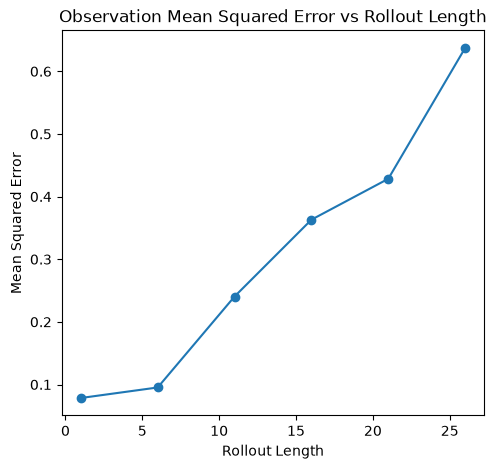

In [4]:
h5_path = "../data/pusht_expert_train.h5"
config_path = "../config/transpressor_v1.yaml"
checkpoint = "../checkpoints/lewm_epoch_4.pt"
device = "mps"

config = OmegaConf.load(config_path)
jepa = build_jepa(config, checkpoint, device)
preprocessor = AutoImageProcessor.from_pretrained(config.pixel_preprocessor.model_name)

def preprocess_frame(preprocessor, frame, device):
    """frame: (H, W, 3) uint8 -> (1, C, crop, crop) preprocessed pixel tensor."""
    return preprocessor([frame], return_tensors="pt")["pixel_values"].to(device)

def cosine_similarity(pred_emb, target_emb):
    """pred_emb, target_emb: (..., D) embeddings with matching shape -> scalar cosine similarity."""
    return torch.nn.functional.cosine_similarity(pred_emb, target_emb, dim=-1).item()

# Create a list of episode lengths, starting at 1 to 30 spaced equally by 5
lengths = list(range(1, 31, 5))
mses = []
cos_sims = []
n = 0
with h5py.File(h5_path, "r") as data:
    for length in lengths:
        avg_mse = 0
        avg_cos_sim = 0

        # Sample 100 unique datapoints from dataset, and sort increasingly
        data_indices = torch.randperm(len(data["ep_offset"]))[:100]
        data_indices = torch.sort(data_indices)[0].numpy()

        for offset, ep_len in tqdm(zip(data["ep_offset"][data_indices], data["ep_len"][data_indices]), total=100):
            if ep_len < length + 2:
                continue  # Skip episodes that are too short for the desired rollout length

            # Sample a random starting point in the episode, ensuring that we have enough frames to sample the desired length
            start = torch.randint(0, ep_len - length - 1, (1,)).item()
            offset = offset + start

            frame = torch.tensor(data["pixels"][offset]).to(device)  # (H, W, C)

            obs = preprocess_frame(preprocessor, frame, device).unsqueeze(0)  # (1, 1, C, crop, crop)
            acts = torch.tensor(data["action"][offset : offset + length]).reshape(1, length, 2).to(device) # (B, S, T, act_dim)

            target_frame = torch.tensor(data["pixels"][offset + length + 1]).to(device) # (H, W, C)
            target = preprocess_frame(preprocessor, target_frame, device).unsqueeze(0) # (1, 1, C, crop, crop)
            target_emb = jepa.encode_pixels(target)  # (1, 1, D_pred)

            act_emb = jepa.encode_actions(acts, torch.tensor([acts.shape[1]]).to(device)).unsqueeze(0)  # (1, 1, 1, D_cond)

            # print(f"obs shape: {obs.shape}\nacts shape: {acts.shape}\ntarget_emb shape: {target_emb.shape}\nact_emb shape: {act_emb.shape}")

            pred_emb = jepa.rollout(obs, act_emb)

            # print(f"\nact_emb shape: {act_emb.shape}\npred_emb shape: {pred_emb.shape}\ntarget_emb shape: {target_emb.shape}")
            mse = torch.mean((pred_emb - target_emb) ** 2).item()
            cos_sim = cosine_similarity(pred_emb, target_emb)

            avg_mse += mse
            avg_cos_sim += cos_sim
            n += 1

        mses.append(avg_mse / n)
        cos_sims.append(avg_cos_sim / n)
        n = 0


# Use matplotlib to plot the results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(lengths, mses, marker='o')
plt.title('Observation Mean Squared Error vs Rollout Length')
plt.xlabel('Rollout Length')
plt.ylabel('Mean Squared Error')
# plt.subplot(1, 2, 2)
# plt.plot(lengths, cos_sims, marker='o', color='orange')
# plt.title('Cosine Similarity vs Rollout Length')
# plt.xlabel('Rollout Length')
# plt.ylabel('Cosine Similarity')
# plt.tight_layout()
plt.show()


In [ ]:
import logging
import evotorch
from evotorch.algorithms import CEM

logging.getLogger("evotorch").setLevel(logging.WARNING)

# Create a list of episode lengths, starting at 1 to 30 spaced equally by 5
lengths = list(range(1, 31, 5))
mses = []
cos_sims = []
fitness_scores = []
n = 0

@torch.inference_mode()
def plan_with_cem(jepa, pixels_hist, goal_pixels, plan_steps, cond_dim, popsize, parenthood_ratio, generations, device):
    # print("Pixel history shape:", pixels_hist.shape)
    def fitness(solutions):
        popsize = solutions.shape[0]
        latent_actions = solutions.view(1, popsize, plan_steps, cond_dim)
        cost = jepa.get_cost(pixels_hist, goal_pixels, latent_actions)
        # An undertrained predictor can occasionally diverge for a given latent draw; treat
        # that candidate as maximally bad rather than letting a NaN poison CEM's mean/stdev.
        cost = torch.nan_to_num(cost, nan=1e6, posinf=1e6)
        return cost.view(popsize)

    problem = evotorch.Problem(
        "min",
        fitness,
        solution_length=plan_steps * cond_dim,
        dtype=torch.float32,
        device=device,
        vectorized=True,
    )
    searcher = CEM(
        problem,
        popsize=popsize,
        parenthood_ratio=parenthood_ratio,
        stdev_init=1.0,
        center_init=0.0,
    )
    searcher.run(generations)

    best = searcher.status["pop_best"]
    return best.values.view(plan_steps, cond_dim), float(best.evals[0])



with h5py.File(h5_path, "r") as data:
    for length in lengths:
        avg_mse = 0
        avg_cos_sim = 0
        avg_fitness = 0
        
        # Sample 100 unique datapoints from dataset, and sort increasingly
        data_indices = torch.randperm(len(data["ep_offset"]))[:100]
        data_indices = torch.sort(data_indices)[0].numpy()

        for offset, ep_len in tqdm(zip(data["ep_offset"][data_indices], data["ep_len"][data_indices]), total=100):
            if ep_len < length + 2:
                continue  # Skip episodes that are too short for the desired rollout length

            # Sample a random starting point in the episode, ensuring that we have enough frames to sample the desired length
            start = torch.randint(0, ep_len - length - 1, (1,)).item()
            offset = offset + start

            frame = torch.tensor(data["pixels"][offset]).to(device)  # (H, W, C)

            obs = preprocess_frame(preprocessor, frame, device).unsqueeze(0)  # (1, 1, C, crop, crop)
            acts = torch.tensor(data["action"][offset : offset + length]).reshape(1, length, 2).to(device) # (B, S, T, act_dim)

            target_frame = torch.tensor(data["pixels"][offset + length + 1]).to(device) # (H, W, C)
            target = preprocess_frame(preprocessor, target_frame, device)# .unsqueeze(0) # (1, 1, C, crop, crop)
            target_emb = jepa.encode_pixels(target.unsqueeze(0))  # (1, 1, D_pred)

            popsize = 30
            parenthood_ratio = 0.2
            generations = 10

            best_action, fitness = plan_with_cem(jepa, obs, target, length, config.transpressor.condition_dim, popsize, parenthood_ratio, generations, device)
            best_action = best_action.expand(1, 1, -1, 5)

            pred_emb = jepa.rollout(obs, best_action)
            # print(f"\nact_emb shape: {act_emb.shape}\npred_emb shape: {pred_emb.shape}\ntarget_emb shape: {target_emb.shape}")
            
            mse = torch.mean((pred_emb - target_emb) ** 2).item()
            cos_sim = cosine_similarity(pred_emb, target_emb)

            avg_mse += mse
            avg_cos_sim += cos_sim
            avg_fitness += fitness

            n += 1


        mses.append(avg_mse / n)
        cos_sims.append(avg_cos_sim / n)
        fitness_scores.append(avg_fitness / n)
        n = 0


# Use matplotlib to plot the results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(lengths, mses, marker='o')
plt.title('Observation Mean Squared Error vs Rollout Length')
plt.xlabel('Rollout Length')
plt.ylabel('Mean Squared Error')

plt.subplot(1, 2, 2)
plt.plot(lengths, cos_sims, marker='o', color='orange')
plt.title('Cosine Similarity vs Rollout Length')
plt.xlabel('Rollout Length')
plt.ylabel('Cosine Similarity')

plt.subplot(1, 2, 2)
plt.plot(lengths, fitness_scores, marker='o', color='green')
plt.title('Fitness Score vs Rollout Length')
plt.xlabel('Rollout Length')
plt.ylabel('Fitness Score')

plt.tight_layout()
plt.show()

  0%|          | 0/100 [00:00<?, ?it/s]


RuntimeError: The expanded size of the tensor (1) must match the existing size (6) at non-singleton dimension 2.  Target sizes: [1, 1, 1, 5].  Tensor sizes: [6, 5]